# Numpy介绍

         

NumPy 是 Numerical Python 的简称，是高性能计算和数据分析的基础包。

虽然Python是用于通用编程的优秀工具，具有高度可读的语法，丰富而强大的数据类型（字符串，列表，集合，字典，数字等）以及非常全面的标准库，

特别是，Python列表是非常灵活的容器，可以任意深度嵌套，并且可以容纳任何Python对象，但它并不是专为数学和科学计算而设计，并不不适合有效地表示常用

的数学结构（向量和矩阵）。 

其语言和标准库中都没有用于多维数据集高效表示的工具，线性代数工具和一般矩阵操作（实际上是所有技术计算的基本组成部分）。

那么是否能够精通理解数组的思维，掌握面向数组的编程，将会为你的Python生涯奠定坚实的根基。其实Numpy本身并没有很多的高级数据分析的功能。

本章所介绍的 NumPy 基础主要是作为未来学习和使用 Pandas 包进行数据分析, 所以不会提及太复杂的内容。首先对比列表，认识Nupmy数组；随后进阶掌握

ndarray，学习Numpy的高效运算。

## 1. 对比列表认识数组

### （1）创建一个列表和一个一维数组

In [6]:
import numpy as np

In [34]:
import sys
from datetime import datetime
import numpy as np

In [3]:
def pythonsum(n):
    a = list(range(n))
    b = list(range(n))
    c = []
    for i in range(len(a)):
        a[i] = i *2
        b[i] = i *3
        c.append(a[i] + b[i])
    print(a)
    print(b)
    print(c)
    print(range(10))
    return c

pythonsum(10)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
[0, 3, 6, 9, 12, 15, 18, 21, 24, 27]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
range(0, 10)


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45]

In [10]:
list(range(6))*2

[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5]

In [8]:
np.arange(6)

array([0, 1, 2, 3, 4, 5])

In [5]:
def numpysum(n):
       a = np.arange(n) * 2
        
       b = np.arange(n) * 3
    
       c = a + b

       return c

numpysum(10)


array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [7]:
import sys
from datetime import datetime
import numpy as np

size = input('input a num ')
size=int(size)
start = datetime.now()
c = pythonsum(size)
delta = datetime.now() - start
print ("The last 2 elements of the sum", c[-2:])
print ("PythonSum elapsed time in microseconds", delta.microseconds)

input a num 10000
The last 2 elements of the sum [49990, 49995]
PythonSum elapsed time in microseconds 18001


In [8]:
size = input('input a num ')
size=int(size)
start = datetime.now()
c = numpysum(size)
delta = datetime.now() - start
print ("The last 2 elements of the sum", c[-2:])
print ("NumPySum elapsed time in microseconds", delta.microseconds)

input a num 10000
The last 2 elements of the sum [49990 49995]
NumPySum elapsed time in microseconds 0


### （2）对比列表与数组的索引

In [7]:
list1=[5,10,15,20]
print(list1)
type(list1)


[5, 10, 15, 20]


list

In [8]:
arr1=np.array([5,10,15,20])
print (arr1)
type(arr1)

[ 5 10 15 20]


numpy.ndarray

In [9]:
arr2=np.array(["c","A","b"])
#print (arr1)
print (arr2)
type(arr2)


['c' 'A' 'b']


numpy.ndarray

In [9]:
#dir(arr2)

In [8]:
list1[0]

5

In [16]:
arr1

array([ 5, 10, 15, 20])

In [11]:
arr1[0]

5

In [12]:
list1[:2]

[5, 10]

In [13]:
arr1[:2]

array([ 5, 10])

### （3）列表与数组的不同

列表和数组之间的第一个区别是数组是同类的; 即数组的所有元素必须具有相同的类型。相反，列表可以包含任意类型的元素。例如，我们可以将上面列表中的最后一个元素更改为一个字符串。

In [10]:
list1[-1]="CDA"
list1

[5, 10, 15, 'CDA']

In [11]:
arr1[-1]="CDA"

ValueError: invalid literal for int() with base 10: 'CDA'

In [14]:
arr1[-1]="1"
#arr1[-2]=False
arr1

array([ 5, 10, 15,  1])

### 2.ndarray

### 通过与列表的对比，我们已经初步认识了Numpy数组的创建方法，Numpy数组的属性索引以及数据类型。
### 实际上NumPy数组是一个多维数组对象，称之为ndarray。关于NumPy数组首先需要掌握的就是：
### 1）NumPy数组的下标从0开始。
### 2）同一个NumPy数组中所有元素的类型必须是相同的。


### （1）在正式深度探索之前，我们首先对数组的基础知识有个初步的认识。
NumPy数组的维数称为秩（rank），一维数组的秩为1，二维数组的秩为2，以此类推。在NumPy中，每一个线性的数组称为是一个轴（axes），秩其实是描述轴的数量。比如说，二维数组相当于是两个一维数组，其中第一个一维数组中每个元素又是一个一维数组。所以一维数组就是NumPy中的轴（axes），第一个轴相当于是底层数组，第二个轴是底层数组里的数组。而轴的数量—秩，就是数组的维数。

### NumPy的数组中比较重要的属性函数有：
ndarray.ndim：数组的维数（即数组轴的个数），等于秩。最常见的为二维数组（矩阵）。

ndarray.shape：数组的维度。为一个表示数组在每个维度上大小的整数元组。例如二维数组中，表示数组的“行数”和“列数”。ndarray.shape返回一个元组，这个元组的长度就是维度的数目，即ndim属性。

ndarray.size：数组元素的总个数，等于shape属性中元组元素的乘积。

ndarray.dtype：表示数组中元素类型的对象，可使用标准的Python类型创建或指定dtype。另外也可以查看数组的数据类型。

ndarray.itemsize：数组中每个元素的字节大小。例如，一个元素类型为float64的数组itemsiz属性值为8(float64占用64个bits，每个字节长度为8，所以64/8，占用8个字节），又如，一个元素类型为complex32的数组item属性为4（32/8）。

ndarray.data：包含实际数组元素的缓冲区，由于一般通过数组的索引获取元素，所以通常不需要使用这个属性。

### Numpy中的基本数据类型

bool	用一个字节存储的布尔类型（True或False）
int8	一个字节大小，-128 至 127
int16	整数，-32768 至 32767
int32	整数，-2 ** 31 至 2 ** 32 -1
int64	整数，-2 ** 63 至 2 ** 63 - 1
uint8	无符号整数，0 至 255
uint16	无符号整数，0 至 65535
uint32	无符号整数，0 至 2 ** 32 - 1
uint64	无符号整数，0 至 2 ** 64 - 1
float16	半精度浮点数：16位，正负号1位，指数5位，精度10位
float32	单精度浮点数：32位，正负号1位，指数8位，精度23位
float64或float	双精度浮点数：64位，正负号1位，指数11位，精度52位
complex64	复数，分别用两个32位浮点数表示实部和虚部
complex128或complex	复数，分别用两个64位浮点数表示实部和虚部

### NumPy数据类型的转换

In [13]:
arr1

array([ 5, 10, 15,  1])

### （2）数组的创建

### 数组的创建方式有很多种，本节课我们主要讲解常见的创建数组的方法。


### 第一种就是我们在开篇用到的创建数组的方式：使用array函数从常规的 list， tuple等格式的数据转创建为ndarray， 默认创建一个新的数组，所创建的数组类型由原序列中的元素类型推导而来。　　　

In [10]:
lis2=[1.1,1.2,1.3,1.4,1.5]
arr2=np.array(lis2)
print(arr2)
print(arr2.shape)
#type(arr2)

[1.1 1.2 1.3 1.4 1.5]
(5,)


In [11]:
lst3=[[1,2,3,4],[5,6,7,8]]
arr3=np.array(lst3)
print(arr3)
print(arr3.shape)

[[1 2 3 4]
 [5 6 7 8]]
(2, 4)


### 可使用双重序列来表示二维的数组，三重序列表示三维数组，以此类推。

In [13]:
lst3=[[1.0,2,3,4],[5,6,7,8],[9,10,11,12]]
arr3=np.array(lst3)
arr3
print(arr3)
print("维数",arr3.ndim)
print("维度",arr3.shape)
print("总个数",arr3.size)
print("对象类型",arr3.dtype)
#arr3.itemsize

[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
维数 2
维度 (3, 4)
总个数 12
对象类型 float64


In [32]:
#arr3[1,1]
print("arr3全部值：\n",arr3)
print("arr3的0行元素：\n",arr3[0,:])#输出0行的全部元素
print("arr3的（0,0）号元素",arr3[0,0])
print("arr3的第三行[1,3)元素",arr3[2,1:3])

arr3全部值：
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
arr3的0行元素：
 [1. 2. 3. 4.]
arr3的（0,0）号元素 1.0
arr3的第三行[1,3)元素 [10. 11.]


In [30]:
#6  7
print(arr3[:,1])
print(arr3[1, 1:3])
print(arr3[1, 1:])
print(arr3[2,(0,3)])

[ 2.  6. 10.]
[6. 7.]
[6. 7. 8.]
[ 9. 12.]


In [26]:
arr3[[0,2],[3,0]]

array([4, 9])

In [34]:
arr3[1:3,(1,3)]

array([[ 6.,  8.],
       [10., 12.]])

In [28]:
lst4=[[[1,2,0,3,4],[1,2,0,3,4]],[[5,6,0,7,8],[1,2,0,3,4]],[[9,10,0,11,12],[1,2,0,3,4]]]
arr4=np.array(lst4)
arr4
print(arr4)
print(arr4.ndim)
print(arr4.shape)
print(arr4.size)
print(arr4.dtype)


[[[ 1  2  0  3  4]
  [ 1  2  0  3  4]]

 [[ 5  6  0  7  8]
  [ 1  2  0  3  4]]

 [[ 9 10  0 11 12]
  [ 1  2  0  3  4]]]
3
(3, 2, 5)
30
int32


### 第二种方法的应用场景是很多时候我们对所创建的数组内的元素未知，但数组的大小已知。针对这种情况，NumPy提供了一些使用占位符创建数组的函数，也就是说一个常量值初始化一个数组，比如：用函数zeros可创建一个全是0的数组，用函数ones可创建一个全为1的数组，函数empty创建一个内容随机并且依赖与内存状态的数组（默认数组类型(dtype)为float64）。这些函数有助于满足除了数组扩展的需要，同时降低了高昂的运算开销。

In [17]:
#print(np.zeros(5,dtype=int))
np.zeros(5,dtype=int)

array([0, 0, 0, 0, 0])

In [18]:
print(np.zeros(5,dtype=complex))

[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [19]:
np.zeros((2,3),int)

array([[0, 0, 0],
       [0, 0, 0]])

In [20]:
np.ones((2, 3))

array([[1., 1., 1.],
       [1., 1., 1.]])

In [21]:
arr2

array(['c', 'A', 'b'], dtype='<U1')

In [34]:
arr3

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [23]:
np.ones_like(arr3)

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [24]:
np.zeros_like(arr3)

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [44]:
np.linspace(0, 10, 10,endpoint=True,retstep=True)
#linspace函数通过指定开始值、终值和元素个数来创建一维数组，可以通过endpoint关键字指定是否包括终值，缺省设置是包括终值:


(array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
         5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ]),
 1.1111111111111112)

In [48]:
#np.linspace(0, 10,num=100)

In [37]:
np.linspace?

In [38]:
np.linspace(0, 1, 12,endpoint=False,retstep=False)

array([0.        , 0.08333333, 0.16666667, 0.25      , 0.33333333,
       0.41666667, 0.5       , 0.58333333, 0.66666667, 0.75      ,
       0.83333333, 0.91666667])

In [27]:
 np.linspace(2.0, 3.0, num=5, retstep=True)

(array([ 2.  ,  2.25,  2.5 ,  2.75,  3.  ]), 0.25)

## dknaondowid

# dkdnpw


### 那么如果我们想要用任意值创建一个初始化的数组，该如何操作？

### 我们可以创建一个空数组，然后使用fill方法将所需的值放入数组中：

In [25]:
a=np.empty(5)
a=np.zeros(5)
a.fill(5.5)
a

array([5.5, 5.5, 5.5, 5.5, 5.5])

In [41]:
np.empty((2,3)) #创建空数组, 类似 np.ones. 其中每个元素都没有进行初始化, 并不能保证都是 0.

array([[1., 1., 1.],
       [1., 1., 1.]])

In [42]:
arr2

array([1.1, 1.2, 1.3, 1.4, 1.5])

In [43]:
np.empty_like(arr2)

array([1.1, 1.2, 1.3, 1.4, 1.5])

In [26]:
np.eye(4, 3) #创建一个对角线为 1 其他为 0 的矩阵.

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [35]:
np.eye?

Signature:
np.eye(
    N,
    M=None,
    k=0,
    dtype=<class 'float'>,
    order='C',
    *,
    device=None,
    like=None,
)
Docstring:
Return a 2-D array with ones on the diagonal and zeros elsewhere.

Parameters
----------
N : int
  Number of rows in the output.
M : int, optional
  Number of columns in the output. If None, defaults to `N`.
k : int, optional
  Index of the diagonal: 0 (the default) refers to the main diagonal,
  a positive value refers to an upper diagonal, and a negative value
  to a lower diagonal.
dtype : data-type, optional
  Data-type of the returned array.
order : {'C', 'F'}, optional
    Whether the output should be stored in row-major (C-style) or
    column-major (Fortran-style) order in memory.

    .. versionadded:: 1.14.0
device : str, optional
    The device on which to place the created array. Default: None.
    For Array-API interoperability only, so must be ``"cpu"`` if passed.

    .. versionadded:: 2.0.0
like : array_like, optional
    Reference

In [27]:
np.identity(3)   #创建一个主对角线为 1 其他为 0 的方阵.

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### 第三种常见的创建数组的方法.我们可以使用 arange方法，创建数组序列。

In [28]:
list(range(1,10,2))


[1, 3, 5, 7, 9]

In [29]:
np.arange(5)

array([0, 1, 2, 3, 4])

In [30]:
b=np.arange(5)
b

array([0, 1, 2, 3, 4])

In [40]:
c=np.arange(10,30,5)
c

array([10, 15, 20, 25])

### 第四种创建随机数组
最后，创建具有随机数字的数组通常是非常有用的。 np.random模块包含许多可用于此效果的函数，例如，这将生成一个从标准正态分布（0均值和方差1）中抽取的5个随机样本数组：

In [31]:
d=np.random.randn(7)
d

array([-0.69425177, -0.32557695,  0.3611806 ,  0.53497877, -1.59794011,
       -0.72874792, -0.6701122 ])

In [36]:
np.random.randn?

Signature: np.random.randn(*args)
Docstring:
randn(d0, d1, ..., dn)

Return a sample (or samples) from the "standard normal" distribution.

.. note::
    This is a convenience function for users porting code from Matlab,
    and wraps `standard_normal`. That function takes a
    tuple to specify the size of the output, which is consistent with
    other NumPy functions like `numpy.zeros` and `numpy.ones`.

.. note::
    New code should use the
    `~numpy.random.Generator.standard_normal`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

If positive int_like arguments are provided, `randn` generates an array
of shape ``(d0, d1, ..., dn)``, filled
with random floats sampled from a univariate "normal" (Gaussian)
distribution of mean 0 and variance 1. A single float randomly sampled
from the distribution is returned if no argument is provided.

Parameters
----------
d0, d1, ..., dn : int, optional
    The dimensions of the returned 

In [49]:
 np.random.normal?

In [46]:
e=np.random.normal(10,3,(2,4))
e

array([[  7.54926192,  10.04946745,  11.68281199,   7.80362849],
       [  3.87600948,   8.70127565,  12.29341334,   6.76293518]])

In [51]:
?np.random.normal

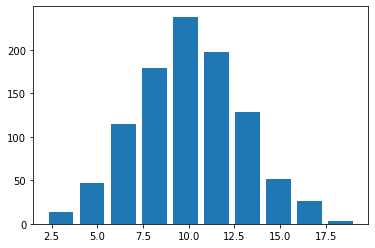

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
d=np.random.randn(1000)
e=np.random.normal(10,3,(1000))
#print(e)

plt.hist(e, histtype='bar',rwidth=0.8)
plt.show()

### （3）数组的索引\切片与遍历

### 上面我们看到了如何对一维数组进行索引切片，就像Python列表一样。 ：

In [35]:
arr=np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [36]:
arr[2]

2

In [37]:
arr[2:5]

array([2, 3, 4])

In [38]:
a=np.arange(24)
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [39]:
#b = np.arange(24).reshape(6,4)
b=a.reshape(6,4)
print(b)
#print(a)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [54]:
b[:,1]

#练习
#1、[ 4,  5,  6,  7]
#2、17, 18
#3、 13,14,17,18
#4、 13,15,17,19
print(b[1,:])
print(b[4,(1,2)])
print(b[3:5,(1,2)])
print(b[3:5,(1,3)])

[4 5 6 7]
[17 18]
[[13 14]
 [17 18]]
[[13 15]
 [17 19]]


In [59]:
print(b.ravel())# 会修改视图，节省内存
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [58]:
print(b.flatten())# 只读展平，不影响原数组
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


### 多维数组

In [60]:
def func1(x):
    return x*2
arr=np.fromfunction(func1,(5,))
arr

array([0., 2., 4., 6., 8.])

```python
numpy.fromfunction(function, shape, *, dtype=float, like=None)
```
参数说明：
function: 一个 Python 函数，接收形如 (i, j, ...) 的索引坐标数组作为参数；

shape: 输出数组的形状；

dtype: 数据类型（默认是 float）；

like: 支持 array-like 对象（NumPy 1.20+）；

In [24]:
np.fromfunction?

In [64]:
def f(x,y):
    return 10*x+y

In [65]:
arr2=np.fromfunction(f,(5,4),dtype=int)
arr2

array([[ 0,  1,  2,  3],
       [10, 11, 12, 13],
       [20, 21, 22, 23],
       [30, 31, 32, 33],
       [40, 41, 42, 43]])

In [66]:
arr2[2,3]

np.int64(23)

In [67]:
arr2[-2]

array([30, 31, 32, 33])

In [68]:
print(arr2[0:3,0:2])

[[ 0  1]
 [10 11]
 [20 21]]


In [62]:
print(arr2[1:6])
print(arr2[1:5])
arr2[1:6]

[1.2 1.3 1.4 1.5]
[1.2 1.3 1.4 1.5]


array([1.2, 1.3, 1.4, 1.5])

In [74]:
arr2

array([[ 0,  1,  2,  3],
       [10, 11, 12, 13],
       [20, 21, 22, 23],
       [30, 31, 32, 33],
       [40, 41, 42, 43]])

In [76]:
arr2[:2,1:]

array([[ 1,  2,  3],
       [11, 12, 13]])

In [70]:
import numpy as np
a = np.array([0, 1, 2, 3, 4, 5, 6])
print(a[2:5])     # [2 3 4]
print(a[:4])      # [0 1 2 3]
print(a[::2])     # [0 2 4 6]
print(a[::-1])    # [6 5 4 3 2 1 0] 反转


[2 3 4]
[0 1 2 3]
[0 2 4 6]
[6 5 4 3 2 1 0]


In [71]:
b = np.array([[10, 11, 12],
              [13, 14, 15],
              [16, 17, 18]])

print(b[0:2, 1:3])   # 前两行，第2和第3列
# 输出：
# [[11 12]
#  [14 15]]

print(b[:, 1])       # 所有行的第2列 => [11 14 17]

print(b[1])          # 第2行 => [13 14 15]


[[11 12]
 [14 15]]
[11 14 17]
[13 14 15]


| 用法            | 说明                    |
| ------------- | --------------------- |
| `a[: , n]`    | 取所有行的第 n 列            |
| `a[m , :]`    | 取第 m 行的所有列            |
| `a[m:n, x:y]` | 子矩阵                   |
| `a[::k, ::k]` | 每 k 步取样（下采样）          |
| `a[::-1]`     | 数组反转                  |
| `a.copy()`    | 切片默认是视图，用 copy() 变为副本 |


### 如果只想遍历整个array可以直接使用

In [75]:
arr3=np.random.normal(10,3,[2,4])
arr3

array([[12.52454731,  9.13690898, 16.42445957, 11.99398921],
       [ 6.95311337,  9.0502766 ,  9.8865808 , 13.50267947]])

In [76]:
print(arr3[1,2:3])
print(arr3[:,2])


[9.8865808]
[16.42445957  9.8865808 ]


In [77]:
lst=[[1,2,3],[4,5,6]]
print(lst)
[i[2] for i in lst ]

[[1, 2, 3], [4, 5, 6]]


[3, 6]

In [78]:
arr4=arr3.reshape(4,2)
arr4

array([[12.52454731,  9.13690898],
       [16.42445957, 11.99398921],
       [ 6.95311337,  9.0502766 ],
       [ 9.8865808 , 13.50267947]])

In [79]:
arr4+1

array([[13.52454731, 10.13690898],
       [17.42445957, 12.99398921],
       [ 7.95311337, 10.0502766 ],
       [10.8865808 , 14.50267947]])

In [80]:
for row in arr4:
    print(row)

[12.52454731  9.13690898]
[16.42445957 11.99398921]
[6.95311337 9.0502766 ]
[ 9.8865808  13.50267947]


In [83]:
plus=0
for row in arr4:
    for i in row:
           print(i+plus)
    plus=plus+1
    print(row)

12.52454731446786
9.136908977172409
[12.52454731  9.13690898]
17.424459572999563
12.993989213268543
[16.42445957 11.99398921]
8.953113365341128
11.050276599231971
[6.95311337 9.0502766 ]
12.88658080347851
16.502679472779175
[ 9.8865808  13.50267947]


In [84]:
arr3d = np.arange(1,13).reshape((2,2,3))
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

# 布尔型索引

In [85]:
word = np.array(list('abcabcdeba'))
word

array(['a', 'b', 'c', 'a', 'b', 'c', 'd', 'e', 'b', 'a'], dtype='<U1')

In [86]:
print(word == 'a')
# sum(word == 'a')


[ True False False  True False False False False False  True]


In [87]:
from numpy.random import randn
data = randn(10,4)
data

array([[ 1.61670274,  0.29766252,  0.09173469, -0.02423502],
       [ 0.44530114, -0.82893314,  0.82927723,  1.87165669],
       [ 1.32103759,  0.08205017,  1.84841776,  0.25957381],
       [-0.76389502, -0.09091649,  0.37088855,  1.01825778],
       [ 0.12337585, -0.46375102, -0.61952474, -0.22395537],
       [ 0.79055651, -0.28183191,  1.21449062, -0.09537392],
       [-1.3952113 ,  0.45860276, -1.3110214 ,  0.78349396],
       [-0.46152053,  1.03927881, -0.29519054, -1.38902903],
       [ 0.88092214, -2.33904711, -0.2529537 ,  1.01327602],
       [-2.28764082,  1.57442634,  0.07468457,  0.23963023]])

In [88]:
data[word == 'a']

array([[ 1.61670274,  0.29766252,  0.09173469, -0.02423502],
       [-0.76389502, -0.09091649,  0.37088855,  1.01825778],
       [-2.28764082,  1.57442634,  0.07468457,  0.23963023]])

In [89]:
data[word == 'a', 2:]

array([[ 0.09173469, -0.02423502],
       [ 0.37088855,  1.01825778],
       [ 0.07468457,  0.23963023]])

In [90]:
data[word == 'a', 3]

array([-0.02423502,  1.01825778,  0.23963023])

In [90]:
word != 'a'

array([False,  True,  True, False,  True,  True,  True,  True,  True, False], dtype=bool)

In [91]:
~(word == 'a')

array([False,  True,  True, False,  True,  True,  True,  True,  True,
       False])

In [92]:
mark = (word == 'a') | (word == 'b')
mark

array([ True,  True, False,  True,  True, False, False, False,  True,
        True])

In [69]:
data[mark]

array([[-0.42704248, -0.14871006,  0.00301514, -0.5357786 ],
       [ 0.50006367, -1.62400345,  1.23193292, -0.47601888],
       [-0.00528626, -0.13827096,  1.36449877, -0.29235918],
       [ 0.69305471, -0.22722148, -0.78008761,  1.03761866],
       [-0.86941527,  0.56431009, -1.32207261,  0.72252186],
       [ 0.35062602, -0.27068089,  0.00838818, -0.30936387]])

In [93]:
data

array([[ 1.61670274,  0.29766252,  0.09173469, -0.02423502],
       [ 0.44530114, -0.82893314,  0.82927723,  1.87165669],
       [ 1.32103759,  0.08205017,  1.84841776,  0.25957381],
       [-0.76389502, -0.09091649,  0.37088855,  1.01825778],
       [ 0.12337585, -0.46375102, -0.61952474, -0.22395537],
       [ 0.79055651, -0.28183191,  1.21449062, -0.09537392],
       [-1.3952113 ,  0.45860276, -1.3110214 ,  0.78349396],
       [-0.46152053,  1.03927881, -0.29519054, -1.38902903],
       [ 0.88092214, -2.33904711, -0.2529537 ,  1.01327602],
       [-2.28764082,  1.57442634,  0.07468457,  0.23963023]])

In [71]:
data>0

array([[False, False,  True, False],
       [ True, False,  True, False],
       [False,  True,  True, False],
       [False, False,  True, False],
       [ True, False, False,  True],
       [ True, False, False,  True],
       [False, False, False, False],
       [ True,  True,  True, False],
       [False,  True, False,  True],
       [ True, False,  True, False]])

In [47]:
data[data>0]=0
data

array([[ 0.        ,  0.        , -0.39129232, -0.23411915],
       [ 0.        , -1.05556021, -0.5438441 ,  0.        ],
       [-0.28004681,  0.        , -0.25234756,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.0726297 ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -1.38794996,  0.        , -1.26926187],
       [ 0.        ,  0.        ,  0.        , -2.01712096],
       [-1.26848042,  0.        ,  0.        , -0.14520637],
       [-0.93638516, -0.73253067, -0.54206121,  0.        ],
       [-1.21441523,  0.        ,  0.        ,  0.        ]])

In [73]:
(word == 'a') & (word == 'b')

array([False, False, False, False, False, False, False, False, False,
       False])

In [94]:
from numpy.random import randn
data = randn(10,4)
data

array([[ 0.52242125,  0.48599622, -0.71153844, -0.01869842],
       [-1.60837055, -1.61094836,  1.18633314, -0.74619952],
       [-0.92786764, -1.24640748, -0.86023767, -0.01174136],
       [ 0.03858775,  0.18389407,  1.33973462,  0.02174208],
       [-1.77574269,  0.64100546, -0.16751851, -0.28077696],
       [-0.93543966,  0.42361398, -0.08885412, -0.67504093],
       [-0.6978567 ,  2.15075449, -1.13244193, -0.5931795 ],
       [-0.41187806, -0.67837597,  0.12645473,  0.70195409],
       [-0.43165242, -0.31049931,  1.33822926,  0.19312972],
       [-0.20547903, -1.60689057, -0.07841227, -2.6866367 ]])

In [95]:
data

array([[ 0.52242125,  0.48599622, -0.71153844, -0.01869842],
       [-1.60837055, -1.61094836,  1.18633314, -0.74619952],
       [-0.92786764, -1.24640748, -0.86023767, -0.01174136],
       [ 0.03858775,  0.18389407,  1.33973462,  0.02174208],
       [-1.77574269,  0.64100546, -0.16751851, -0.28077696],
       [-0.93543966,  0.42361398, -0.08885412, -0.67504093],
       [-0.6978567 ,  2.15075449, -1.13244193, -0.5931795 ],
       [-0.41187806, -0.67837597,  0.12645473,  0.70195409],
       [-0.43165242, -0.31049931,  1.33822926,  0.19312972],
       [-0.20547903, -1.60689057, -0.07841227, -2.6866367 ]])

In [96]:
data.shape

(10, 4)

In [97]:
data.sum(axis=1)

array([ 0.27818061, -2.77918528, -3.04625415,  1.58395851, -1.5830327 ,
       -1.27572073, -0.27272364, -0.26184521,  0.78920726, -4.57741857])

In [75]:
data.sum(axis=1)>0

array([ True, False, False,  True, False, False, False,  True, False,
       False])

In [98]:
data.sum?

Docstring:
a.sum(axis=None, dtype=None, out=None, keepdims=False, initial=0, where=True)

Return the sum of the array elements over the given axis.

Refer to `numpy.sum` for full documentation.

See Also
--------
numpy.sum : equivalent function
Type:      builtin_function_or_method

In [99]:
data[data.sum(axis=1)>0]
#data.sum()

array([[ 0.52242125,  0.48599622, -0.71153844, -0.01869842],
       [ 0.03858775,  0.18389407,  1.33973462,  0.02174208],
       [-0.43165242, -0.31049931,  1.33822926,  0.19312972]])

In [108]:
data.sum(axis=0)

array([-3.70639701,  1.804523  ,  2.06410476,  0.6220534 ])

# 花式索引

In [105]:
arr = np.empty((7,5))
for i in range(7):
    arr[i] = i
arr

array([[ 0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 2.,  2.,  2.,  2.,  2.],
       [ 3.,  3.,  3.,  3.,  3.],
       [ 4.,  4.,  4.,  4.,  4.],
       [ 5.,  5.,  5.,  5.,  5.],
       [ 6.,  6.,  6.,  6.,  6.]])

In [104]:
arr[[5, 3, 2, 1]]

array([[ 5.,  5.,  5.,  5.,  5.],
       [ 3.,  3.,  3.,  3.,  3.],
       [ 2.,  2.,  2.,  2.,  2.],
       [ 1.,  1.,  1.,  1.,  1.]])

In [106]:
arr[[-1, -3, -5, 1]]

array([[ 6.,  6.,  6.,  6.,  6.],
       [ 4.,  4.,  4.,  4.,  4.],
       [ 2.,  2.,  2.,  2.,  2.],
       [ 1.,  1.,  1.,  1.,  1.]])

In [27]:
arr = np.arange(32).reshape((8,4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [108]:
arr[[1, 5, 7 ,2], [0, 2, 1, 3]]

array([ 4, 22, 29, 11])

In [109]:
arr[[1, 5, 7 ,2]]

array([[ 4,  5,  6,  7],
       [20, 21, 22, 23],
       [28, 29, 30, 31],
       [ 8,  9, 10, 11]])

In [111]:
arr[[1, 5, 7 ,2]][:,[0, 2, 1, 3]]

array([[ 4,  6,  5,  7],
       [20, 22, 21, 23],
       [28, 30, 29, 31],
       [ 8, 10,  9, 11]])

In [110]:
arr[[1, 5, 7 ,2]][:,[0, 2]]

array([[ 4,  6],
       [20, 22],
       [28, 30],
       [ 8, 10]])

In [112]:
arr[[1, 5, 7 ,2]]

array([[ 4,  5,  6,  7],
       [20, 21, 22, 23],
       [28, 29, 30, 31],
       [ 8,  9, 10, 11]])

In [115]:
arr[np.ix_([1, 5, 7 ,2], [0, 2, 1, 3])]

array([[ 0,  6,  5,  7],
       [20,  0, 21, 23],
       [28, 30,  0, 31],
       [ 8, 10,  9,  0]])

In [116]:
arr[[1, 5, 7 ,2], [0, 2, 1, 3]] = 0
arr

array([[ 0,  1,  2,  3],
       [ 0,  5,  6,  7],
       [ 8,  9, 10,  0],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21,  0, 23],
       [24, 25, 26, 27],
       [28,  0, 30, 31]])

### （4）数组的变换
实际上，只要元素的总数不变，数组的形状就可以随时改变。 例如，如果我们想要一个数字从0增加的2x4数组，最简单的方法是：

In [87]:
arr=np.random.normal(8,2,(2,6))
arr

array([[ 9.79792424,  5.88356829,  6.14563   , 10.34993136,  6.95410054,
        10.39721945],
       [11.44882193,  3.8500862 ,  9.83872658,  6.73856947,  5.53294836,
         9.41949974]])

In [88]:
arr.reshape(3,4)

array([[ 9.79792424,  5.88356829,  6.14563   , 10.34993136],
       [ 6.95410054, 10.39721945, 11.44882193,  3.8500862 ],
       [ 9.83872658,  6.73856947,  5.53294836,  9.41949974]])

### 数组的另一个广泛使用的属性是.T属性数组的转置。

In [89]:
arr=np.arange(8)

arr
#id(arr)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [90]:
arr2=arr.reshape(2,4)#view
arr2
#id(arr2)

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [91]:
arr2.T

array([[0, 4],
       [1, 5],
       [2, 6],
       [3, 7]])

In [55]:
arr=np.arange(8)
arr

array([0, 1, 2, 3, 4, 5, 6, 7])

In [57]:
arr2=arr
arr2[1]=1000
print(arr)
print(arr2)

[1000 1000    2    3    4    5    6    7]
[1000 1000    2    3    4    5    6    7]


In [52]:
arr2=arr.reshape(2,4)
arr2

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [58]:
arr2=arr
arr2[1]=1000
print(arr)
print(arr2)

[1000 1000    2    3    4    5    6    7]
[1000 1000    2    3    4    5    6    7]


In [54]:
arr3=arr.copy()#copy
arr3
arr[0]=2000
print(arr)
arr3
#arr4=arr3
#arr4

[2000    1    2    3    4    5    6    7]


array([1000,    1,    2,    3,    4,    5,    6,    7])

In [89]:
arr[0]=5
print(arr)
print(arr2)
print(arr3)
print(arr4)

[5 1 2 3 4 5 6 7]
[[5 1 2 3]
 [4 5 6 7]]
[1000    1    2    3    4    5    6    7]
[[ 8.34968589  8.32826265]
 [14.41501261 10.79554744]
 [ 6.56686174 15.06726606]
 [ 2.93695294  7.72274988]]


In [90]:
arr2.T

array([[5, 4],
       [1, 5],
       [2, 6],
       [3, 7]])

### （5）数组的其他属性

In [84]:
arr4=arr2#view
arr4

array([[2000,    1,    2,    3],
       [   4,    5,    6,    7]])

In [85]:
arr4.dtype

dtype('int32')

In [86]:
arr4.size

8

In [87]:
arr4.ndim

2

In [88]:
arr4.shape

(2, 4)

In [141]:
arr4.nbytes

32

In [89]:
arr4

array([[2000,    1,    2,    3],
       [   4,    5,    6,    7]])

In [97]:
print(arr4.min())

[4 1 2 3]


In [143]:
print(arr4.max())

7


In [96]:
print(arr4.sum())

2028


In [94]:
print(arr4.sum(axis=0))

[2004    6    8   10]


In [95]:
print(arr4.sum(axis=1))

[2006   22]


In [93]:
arr4.sum?

In [83]:
?sum

In [145]:
print(arr4.mean())

4.125


In [124]:
print(arr4.std())

1.8998355192


In [125]:
arr4

array([[5, 1, 2, 3],
       [4, 5, 6, 7]])

In [127]:
print(arr4.sum(axis=1))#by row

[11 22]


In [128]:
print(arr4.sum(axis=0))#by column

[ 9  6  8 10]


In [129]:
arr4.mean(axis=0)

array([ 4.5,  3. ,  4. ,  5. ])

In [103]:
np.mean(arr4)

253.5

### （6）数组的运算

数组支持所有常规算术运算符，而numpy库也包含一组完整的基本数学函数，这些函数在数组上运算。 重要的是要记住，一般来说，数组的所有操作都是以元素的形式应用的，即，同时应用于数组的所有元素。 考虑例如：

In [103]:
arr1=np.arange(4)
arr1

array([0, 1, 2, 3])

In [104]:
arr2=np.arange(10,14)
arr2

array([10, 11, 12, 13])

In [105]:
print(arr1,"+",arr2,"=",arr1+arr2)

[0 1 2 3] + [10 11 12 13] = [10 12 14 16]


重要的是，你必须记住，即使乘法运算符是默认应用于元素的方式，它不是线性代数的矩阵乘法：

In [106]:
print(arr1,"*",arr2,"=",arr1*arr2)

[0 1 2 3] * [10 11 12 13] = [ 0 11 24 39]


我们也可以用一个标量乘一个数组：

In [107]:
print(arr1,"*",1.5,"=",arr1*1.5)

[0 1 2 3] * 1.5 = [0.  1.5 3.  4.5]


In [108]:
arr = np.arange(1, 11)
arr

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [109]:
np.sqrt(arr)

array([1.        , 1.41421356, 1.73205081, 2.        , 2.23606798,
       2.44948974, 2.64575131, 2.82842712, 3.        , 3.16227766])

In [110]:
np.exp(2)

7.38905609893065

In [111]:
np.exp(arr)

array([2.71828183e+00, 7.38905610e+00, 2.00855369e+01, 5.45981500e+01,
       1.48413159e+02, 4.03428793e+02, 1.09663316e+03, 2.98095799e+03,
       8.10308393e+03, 2.20264658e+04])

In [112]:
x = np.random.randn(8)
y = np.random.randn(8)
print (x)
print (y)
np.maximum(x, y)

[ 0.1351039   1.08808486  0.27901483 -0.81039661  1.01968238  0.05840836
  0.5471423   1.05558286]
[-0.39860277  0.01309593  0.33847293 -0.08452496  1.41839764 -0.76184835
 -2.21061222  2.7594264 ]


array([ 0.1351039 ,  1.08808486,  0.33847293, -0.08452496,  1.41839764,
        0.05840836,  0.5471423 ,  2.7594264 ])

In [38]:
arr = randn(5,4)
print(arr)
arr.mean()

[[-0.48436819 -1.35991103 -0.0192448   0.19460926]
 [-0.87905273  0.47221181 -1.06333864 -0.65725676]
 [ 0.52594974 -0.74647923  0.64333301 -0.99891289]
 [-0.72986385 -0.15451442 -0.41656444 -0.77665108]
 [ 0.57928371 -0.61813016  0.84475512  1.33588179]]


-0.21541318922596214

In [39]:
np.mean(arr)

-0.21541318922596214

In [40]:
arr.mean(axis=1)

array([-0.41722869, -0.53185908, -0.14402734, -0.51939845,  0.53544761])

In [41]:
arr.mean(axis=0)

array([-0.19761026, -0.48136461, -0.00221195, -0.18046594])

In [143]:
arr

array([[-0.22793422, -0.86482982, -1.37002166, -1.18615144],
       [ 0.13545958, -0.76937608,  0.58946757,  0.33007905],
       [-1.00178334,  0.16980832, -1.37081388,  0.27688778],
       [-0.35787772, -0.54250148, -1.10275522,  2.24455425],
       [-1.33935884,  0.26587237, -0.58473017,  0.5230939 ]])

In [145]:
arr.sum()


-6.1829110456840946

In [146]:
arr.sum(0)
#arr.sum(1)

array([-2.79149453, -1.7410267 , -3.83885336,  2.18846354])

In [147]:
arr = np.arange(9).reshape((3,3))
arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [111]:
#arr.cumsum(1)
arr.cumprod(0)

array([      1,       2,       6,      24,     120,     720,    5040,
         40320,  362880, 3628800], dtype=int32)

In [105]:
arr.cumprod?

In [59]:
a = np.arange(9).reshape(3,3)
a

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [60]:
b = 2 * a
b

array([[ 0,  2,  4],
       [ 6,  8, 10],
       [12, 14, 16]])

In [61]:
np.hstack((a, b))


array([[ 0,  1,  2,  0,  2,  4],
       [ 3,  4,  5,  6,  8, 10],
       [ 6,  7,  8, 12, 14, 16]])

In [62]:
np.vstack((a, b))

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 0,  2,  4],
       [ 6,  8, 10],
       [12, 14, 16]])

In [111]:
np.column_stack((a, b))
np.row_stack((a, b))

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 0,  2,  4],
       [ 6,  8, 10],
       [12, 14, 16]])

In [47]:
np.column_stack((a, b))==np.hstack((a, b))

array([[ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True]])

### 数组的广播
numpy数组的广播功能强大。

广播原则：
如果两个数组的后缘维度(即：从末尾开始算起的维度)的轴长相符或其中一方的长度为1，则认为它们是广播兼容的，广播会在缺失和(或)长度为1的轴上进行.

In [117]:
print(np.arange(3))

[0 1 2]


In [118]:
print(np.arange(3)*5)

[ 0  5 10]


In [119]:
np.ones((4,3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [120]:
np.arange(3)

array([0, 1, 2])

In [121]:
np.ones((4,3))+ np.arange(3)

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [194]:
np.arange(3).reshape((3,1))+np.arange(3)

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

解析来我们用图解的方式，理解下

### 更强大的数学功能
正如我们之前提到的那样，Numpy提供了完整的数学函数，可以在整个数组上运行，包括对数，指数，三角函数和双曲三角函数等。此外，scipy还在scipy.special模块中提供了一个丰富的特殊函数库 贝塞尔，艾里，菲涅耳，拉盖尔等古典特殊功能。 例如，对0和2π之间的100点的正弦函数进行采样就像下面这样简单：

In [161]:
x=np.linspace(0,2*np.pi,10)
y=np.sin(x)
print(x)
print(y)
print(x,y)

[ 0.          0.6981317   1.3962634   2.0943951   2.7925268   3.4906585
  4.1887902   4.88692191  5.58505361  6.28318531]
[  0.00000000e+00   6.42787610e-01   9.84807753e-01   8.66025404e-01
   3.42020143e-01  -3.42020143e-01  -8.66025404e-01  -9.84807753e-01
  -6.42787610e-01  -2.44929360e-16]
[ 0.          0.6981317   1.3962634   2.0943951   2.7925268   3.4906585
  4.1887902   4.88692191  5.58505361  6.28318531] [  0.00000000e+00   6.42787610e-01   9.84807753e-01   8.66025404e-01
   3.42020143e-01  -3.42020143e-01  -8.66025404e-01  -9.84807753e-01
  -6.42787610e-01  -2.44929360e-16]


### 线性代数（NumPy）
Numpy提供了一个基本的线性代数库，所有的数组都有一个点方法，当它的参数是向量（一维数组）时，其行为是标量点积的行为，而当它的一个或两个参数是两个时，为传统的矩阵乘法：

### 对于矩阵乘法，必须满足相同的维度匹配规则，例如， 考虑A×AT的区别

In [124]:
A=randn(5,4)
A
#len(A)

array([[ 0.63949972,  1.67503359, -0.73544885,  1.71309835],
       [-0.48794766, -1.52135568, -0.47563252, -0.7439447 ],
       [-1.00523107,  0.00908725,  2.87099437, -0.25362455],
       [ 0.93158411,  0.22902521, -0.58675365,  0.00673049],
       [-0.79054324, -1.54093495,  1.17649533,  0.63410033]])

In [125]:
A.T

array([[ 0.63949972, -0.48794766, -1.00523107,  0.93158411, -0.79054324],
       [ 1.67503359, -1.52135568,  0.00908725,  0.22902521, -1.54093495],
       [-0.73544885, -0.47563252,  2.87099437, -0.58675365,  1.17649533],
       [ 1.71309835, -0.7439447 , -0.25362455,  0.00673049,  0.63410033]])

and $A^T \times A$:

In [126]:
print(np.dot(A.T,A))

[[ 3.15034988  3.23592262 -4.6009291   1.21846956]
 [ 3.23592262  7.54727626 -2.42948999  3.0234311 ]
 [-4.6009291  -2.42948999 10.73814109 -0.89213964]
 [ 1.21846956  3.0234311  -0.89213964  3.9546136 ]]


In [199]:
print(np.dot(A,A.T))

[[ 2.28124254 -1.24780403 -1.0031042  -0.30599882 -2.93428232]
 [-1.24780403  4.74146555  2.07095054  0.19684115  4.13648321]
 [-1.0031042   2.07095054  1.88514758  0.52428824  2.02673537]
 [-0.30599882  0.19684115  0.52428824  0.50328024  0.58088271]
 [-2.93428232  4.13648321  2.02673537  0.58088271  5.63423308]]


此外，numpy.linalg模块还包括附加功能，如行列式，矩阵范数，Cholesky，特征值和奇异值分解等。对于更线性的代数工具，scipy.linalg包含经典LAPACK库中的大部分工具 作为在稀疏矩阵上运行的函数。 如果大家想要了解更多关于这些内容，可以去Numpy和Scipy文档中去拓展学习。

# ## 唯一化和集合逻辑

In [127]:
names = np.array(['Atom', 'Lucy', 'Kid', 'Atom', 'Kid', 'Atom'])
names
len(names)

6

In [128]:
np.unique(names)

array(['Atom', 'Kid', 'Lucy'], dtype='<U4')

In [129]:
ints = np.array([1,2,3,4,2,4,3,5])
ints

array([1, 2, 3, 4, 2, 4, 3, 5])

In [130]:
np.unique(ints)

array([1, 2, 3, 4, 5])

In [122]:
val_1 = np.array([4,5,6,2,5,7,4,0])
val_2 = np.array([1,2,3,4,7,8,4,3])

In [132]:
np.in1d(val_1, [0, 5, 7])

array([False,  True, False, False,  True,  True, False,  True])

In [134]:
np.intersect1d(val_1, val_2)

array([2, 4, 7])

In [135]:
np.union1d(val_1, val_2)

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [136]:
np.setdiff1d(val_1, val_2)

array([0, 5, 6])

In [215]:
arr.sort?

In [137]:
val_1.sort()
val_1

array([0, 2, 4, 4, 5, 5, 6, 7])

In [138]:
arr = randn(5, 3)
arr.sort(1,)
arr

array([[-1.76249293, -0.57418624,  0.36488728],
       [-0.16906137, -0.0147706 ,  0.03378827],
       [ 0.24648872,  0.39464743,  1.30129466],
       [-1.2740169 , -1.05221279, -0.75729042],
       [-0.81826791, -0.59608999, -0.22528569]])

In [139]:
arr.sort(0)
arr

array([[-1.76249293, -1.05221279, -0.75729042],
       [-1.2740169 , -0.59608999, -0.22528569],
       [-0.81826791, -0.57418624,  0.03378827],
       [-0.16906137, -0.0147706 ,  0.36488728],
       [ 0.24648872,  0.39464743,  1.30129466]])

# 补充